# Epistasis Heatmap — Edge Perturbation Analysis (3 × 3 Grid)

**Objective**: Prove that our Memetic algorithm discovers a structurally sound architectural *backbone* — not random operation choices — by measuring how sensitive each of the 6 edges is to perturbation across all 3 datasets and 3 hardware targets.

## What is Epistasis?

In neural architecture search, **epistasis** refers to the interaction between edges in the cell graph. When the fitness of the whole network strongly depends on the value of a *single* edge, that edge is said to be **epistatic** (or *sensitive*).

$$\Delta F(e, o) = \text{Acc}(\mathbf{a}) - \text{Acc}(\mathbf{a}[e \leftarrow o])$$

A large $\Delta F$ means that swapping edge $e$ to operation $o$ causes a large accuracy drop — the edge is a critical part of the network's performance.

## Why This Analysis Matters

1. **Validates the algorithm**: If our Memetic approach is genuinely learning structure, the top Pareto-front architectures it finds should cluster around the same high-sensitivity edges (the backbone). Random search would show flat, low-sensitivity maps.
2. **Explains PSO's role**: Discrete PSO in our algorithm uses personal-best and neighbourhood-best to *preserve* the current value of high-sensitivity edges while still allowing exploration of low-sensitivity edges. This heatmap is the empirical evidence for that design choice.
3. **Device-specific backbone**: Different hardware targets penalise different operations. An edge that is critical for EdgeGPU latency may be irrelevant for Eyeriss. The 3 × 3 grid reveals this hardware-dependent sensitivity.

## Interpretation Guide

| Heatmap colour | Meaning |
|---|---|
| **Dark red** (high $\Delta F$) | Critical edge — part of the architectural backbone for this device |
| **Yellow / light** (low $\Delta F$) | Robust edge — safe to mutate without harming accuracy |
| **Grey (masked)** | Self-replacement (op = original op) — not computed |

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    raise FileNotFoundError("Unable to locate the repository root for HW-NAS-Memetic.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.data_processing import get_project_root
assert get_project_root() == PROJECT_ROOT

import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.api.hw_nas_wrapper import HWNASApi
from src.analysis.data_loader import DATASETS, HARDWARE, combo_archive_sets
from src.analysis.epistasis import (
    calculate_edge_sensitivity,
    aggregate_sensitivity,
    select_pareto_archs,
    select_pareto_front_archs,
    edge_brittleness,
    op_disruption,
    N_OPS,
    N_EDGES,
    OPS_NAMES,
)


/home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import time

# ── Configuration ──────────────────────────────────────────────────────────────
HW_BENCH_PATH = PROJECT_ROOT / "data" / "HW-NAS-Bench-v1_0.pickle"
CACHE_PATH    = PROJECT_ROOT / "data" / "nas201_accuracy_cache.npz"
RESULTS_DIR   = PROJECT_ROOT / "results"
OUT_DIR       = RESULTS_DIR / "figures" / "epistasis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

api = HWNASApi(str(HW_BENCH_PATH), nas201_cache_path=str(CACHE_PATH))
print(f"API ready. Cache mode: {'ground-truth' if api._acc_cache else 'proxy'}")
print(f"Datasets : {DATASETS}")
print(f"Hardware : {HARDWARE}")
print(f"Total combos: {len(DATASETS) * len(HARDWARE)}")
print()

# ── Compute sensitivity for every dataset/hardware combination ─────────────────
sensitivity = {}
t_global = time.perf_counter()
n_combos = len(DATASETS) * len(HARDWARE)
combo_idx = 0

for dataset in DATASETS:
    sensitivity[dataset] = {}
    for hw in HARDWARE:
        combo_idx += 1
        print(f"─── [{combo_idx}/{n_combos}] {dataset} / {hw} ───")
        t_combo = time.perf_counter()

        sets = combo_archive_sets(RESULTS_DIR, dataset, hw)
        proposed_archives = sets.get("Proposed", [])
        if not proposed_archives or all(len(a) == 0 for a in proposed_archives):
            sensitivity[dataset][hw] = (None, None, [])
            print(f"  ⚠ no proposed archives found — skipping.\n")
            continue

        # Architecture selection
        archs = select_pareto_front_archs(proposed_archives)
        selector = "Pareto-front"
        if len(archs) < 3:
            archs = select_pareto_archs(proposed_archives, top_k=10)
            selector = "top-K accuracy"
        archs = archs[:10]
        print(f"  selector : {selector}  →  {len(archs)} architectures")
        print(f"  queries  : {len(archs)} archs × {4} alt-ops × {6} edges = "
              f"{len(archs) * 4 * 6} API calls")

        # Sensitivity computation — verbose=True shows per-arch timing
        mean_delta, all_deltas = aggregate_sensitivity(archs, dataset, api, verbose=True)
        sensitivity[dataset][hw] = (mean_delta, all_deltas, archs)

        elapsed = time.perf_counter() - t_combo
        print(f"  ✓ done in {elapsed:.1f}s  "
              f"(mean ΔF range: [{float(mean_delta[~np.isnan(mean_delta)].min()):.2f}, "
              f"{float(mean_delta[~np.isnan(mean_delta)].max()):.2f}]%)\n")

total_elapsed = time.perf_counter() - t_global
print(f"Sensitivity computation complete — total wall time: {total_elapsed:.1f}s")


/home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/src/api/hw_nas_wrapper.py:38: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  self.data = pickle.load(f)


Loading benchmark from /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/data/HW-NAS-Bench-v1_0.pickle...
Accuracy cache loaded (183 KB) — ground-truth mode active.
Benchmark loaded. Available devices: ['nasbench201', 'fbnet']
API ready. Cache mode: ground-truth
Datasets : ['cifar10', 'cifar100', 'ImageNet16-120']
Hardware : ['edgegpu_latency', 'raspi4_latency', 'eyeriss_latency']
Total combos: 9

─── [1/9] cifar10 / edgegpu_latency ───
  selector : Pareto-front  →  10 architectures
  queries  : 10 archs × 4 alt-ops × 6 edges = 240 API calls


  archs: 100%|████████████████████████| 10/10 [00:00<00:00, 4240.95it/s]

  → aggregate done: 10 archs in 0.0s (0.0s/arch)
  ✓ done in 2289.8s  (mean ΔF range: [-0.20, 3.78]%)

─── [2/9] cifar10 / raspi4_latency ───



/home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/src/analysis/epistasis.py:157: RuntimeWarning: Mean of empty slice
  mean_delta = np.nanmean(stack, axis=0)


...

  archs: 100%|████████████████████████| 10/10 [00:00<00:00, 1691.52it/s]

  → aggregate done: 10 archs in 0.0s (0.0s/arch)
  ✓ done in 4545.5s  (mean ΔF range: [-0.69, 8.47]%)

─── [9/9] ImageNet16-120 / eyeriss_latency ───


  selector : Pareto-front  →  10 architectures
  queries  : 10 archs × 4 alt-ops × 6 edges = 240 API calls


  archs: 100%|█████████████████████████| 10/10 [00:00<00:00, 946.50it/s]

  → aggregate done: 10 archs in 0.0s (0.0s/arch)
  ✓ done in 3628.8s  (mean ΔF range: [-1.01, 10.19]%)

Sensitivity computation complete — total wall time: 27529.0s


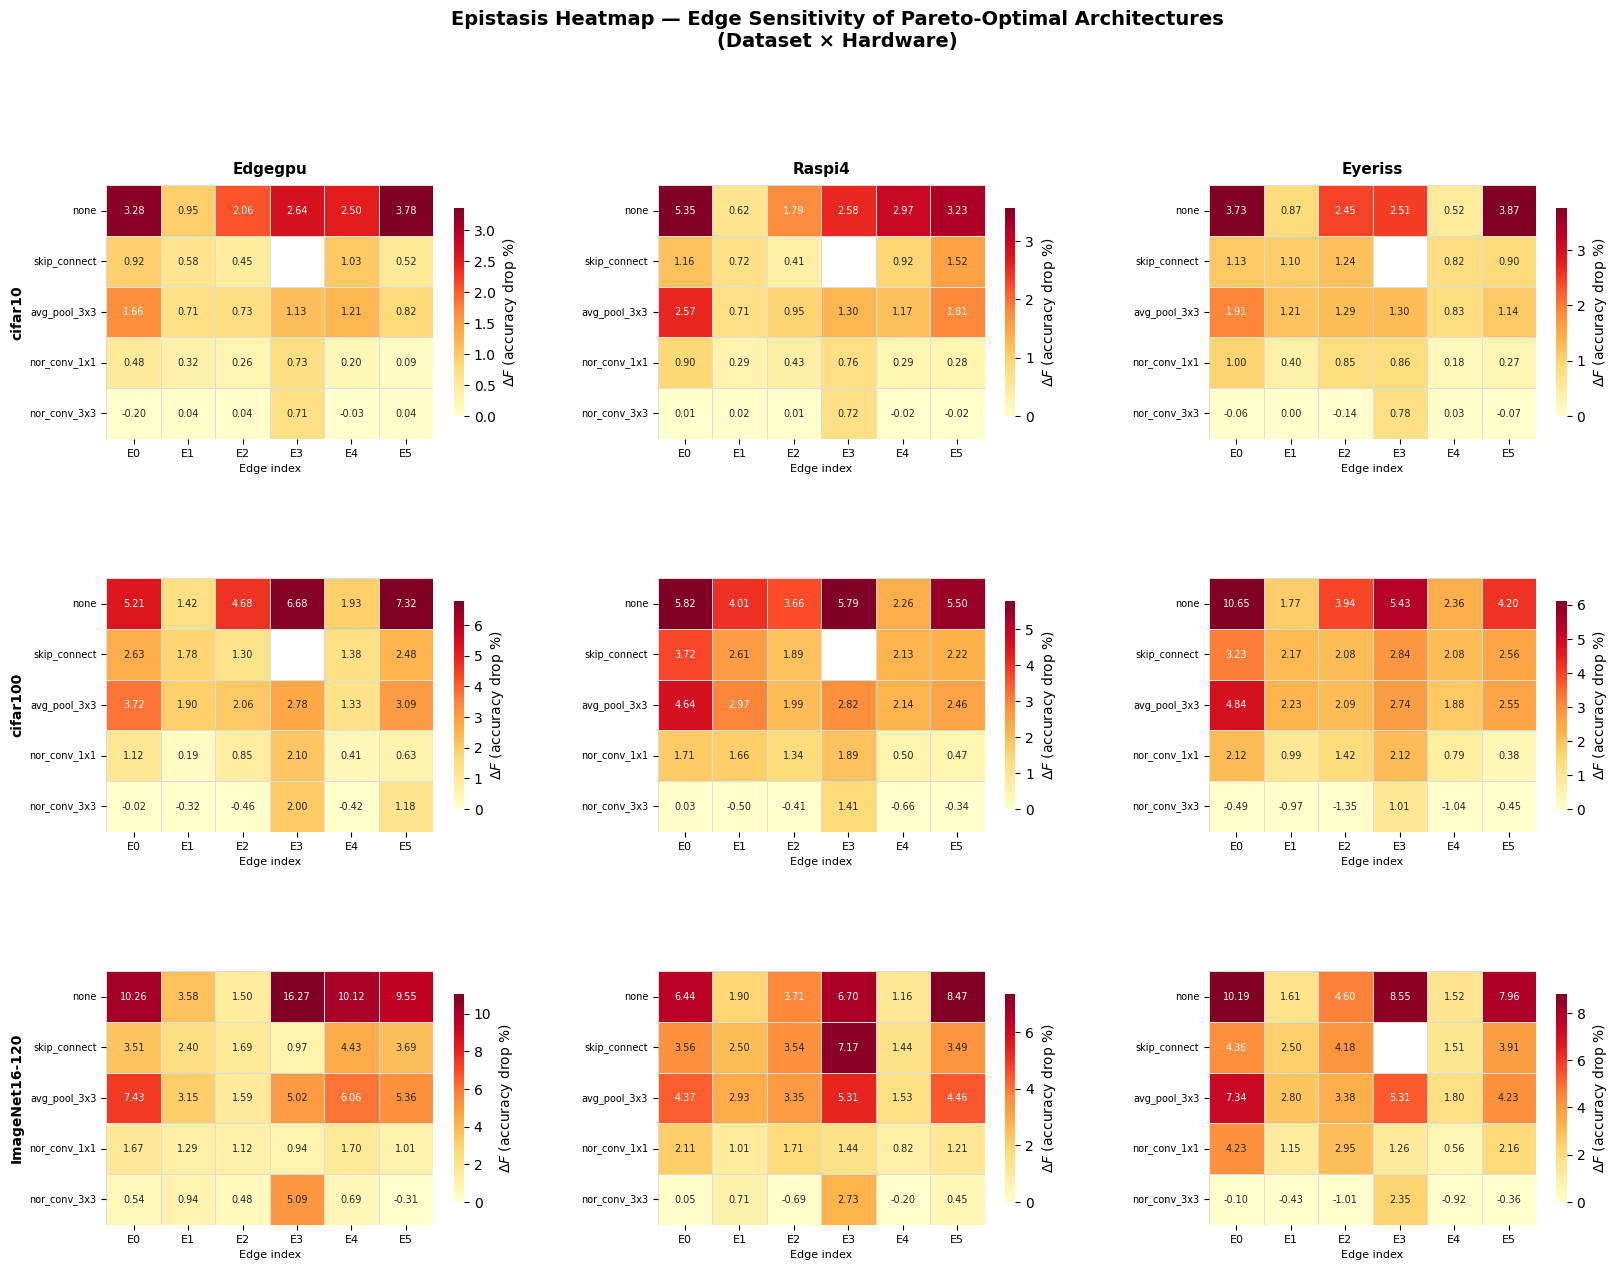

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/epistasis/epistasis_3x3_grid.pdf


In [3]:
fig = plt.figure(figsize=(6.5 * len(HARDWARE), 4.5 * len(DATASETS)))
gs = gridspec.GridSpec(len(DATASETS), len(HARDWARE), figure=fig, hspace=0.55, wspace=0.35)
CMAP = "YlOrRd"

for row_idx, dataset in enumerate(DATASETS):
    for col_idx, hw in enumerate(HARDWARE):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        mean_delta, _, archs = sensitivity[dataset][hw]
        if mean_delta is None or not len(archs):
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="grey")
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            mask = np.isnan(mean_delta)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                vmax = float(np.nanpercentile(mean_delta, 97)) if not mask.all() else 1.0
            sns.heatmap(
                mean_delta,
                ax=ax,
                cmap=CMAP,
                vmin=0.0,
                vmax=vmax,
                annot=True,
                fmt=".2f",
                linewidths=0.4,
                linecolor="#dddddd",
                xticklabels=[f"E{i}" for i in range(N_EDGES)],
                yticklabels=OPS_NAMES,
                mask=mask,
                cbar_kws={"label": r"$\Delta F$ (accuracy drop %)", "shrink": 0.82},
                annot_kws={"size": 7},
            )
            ax.tick_params(axis="x", labelsize=8, rotation=0)
            ax.tick_params(axis="y", labelsize=7, rotation=0)

        if row_idx == 0:
            ax.set_title(hw.replace("_latency", "").replace("_", " ").title(), fontweight="bold", fontsize=11, pad=8)
        if col_idx == 0:
            ax.set_ylabel(dataset, fontweight="bold", fontsize=10)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("Edge index", fontsize=8)

fig.suptitle(
    "Epistasis Heatmap — Edge Sensitivity of Pareto-Optimal Architectures\n"
    "(Dataset × Hardware)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
out_heatmap = OUT_DIR / "epistasis_3x3_grid.pdf"
fig.savefig(out_heatmap, bbox_inches="tight", dpi=180)
plt.show()
print(f"Saved → {out_heatmap}")


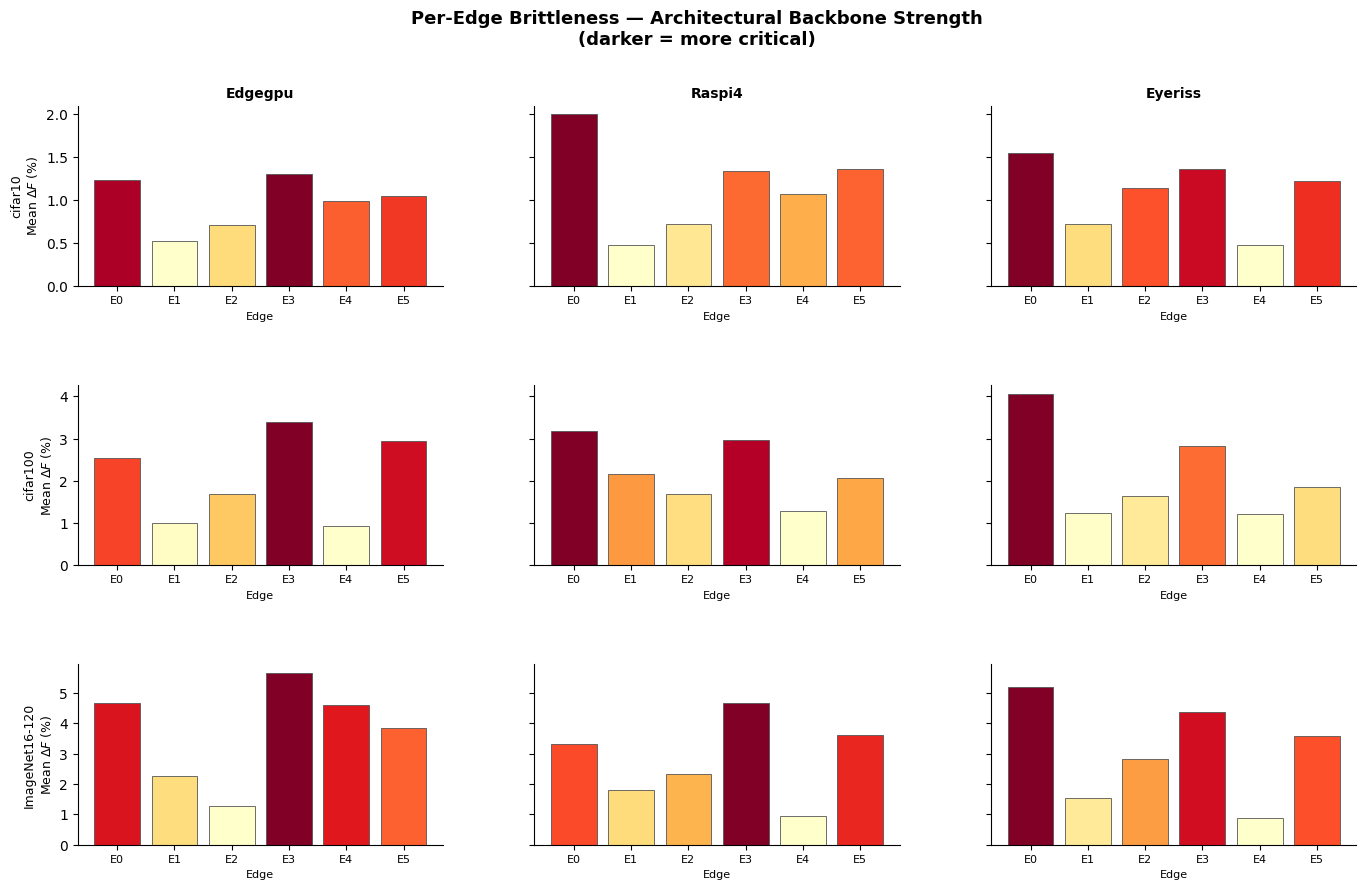

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/epistasis/edge_brittleness_3x3.pdf


In [4]:
fig2, axes2 = plt.subplots(len(DATASETS), len(HARDWARE), figsize=(5.5 * len(HARDWARE), 3.2 * len(DATASETS)), sharey="row")
fig2.subplots_adjust(hspace=0.55, wspace=0.25)

for row_idx, dataset in enumerate(DATASETS):
    for col_idx, hw in enumerate(HARDWARE):
        ax = axes2[row_idx][col_idx]
        mean_delta, _, archs = sensitivity[dataset][hw]
        if mean_delta is None or not len(archs):
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="grey")
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            brit = edge_brittleness(mean_delta)
            colors = plt.cm.YlOrRd((brit - np.nanmin(brit)) / max(np.nanmax(brit) - np.nanmin(brit), 1e-9))
            ax.bar(range(N_EDGES), brit, color=colors, edgecolor="#555", linewidth=0.6)
            ax.set_xticks(range(N_EDGES))
            ax.set_xticklabels([f"E{i}" for i in range(N_EDGES)], fontsize=8)
            ax.set_xlabel("Edge", fontsize=8)
            ax.spines[["top", "right"]].set_visible(False)

        if row_idx == 0:
            ax.set_title(hw.replace("_latency", "").replace("_", " ").title(), fontweight="bold", fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f"{dataset}\nMean $\\Delta F$ (%)", fontsize=9)

fig2.suptitle("Per-Edge Brittleness — Architectural Backbone Strength\n(darker = more critical)", fontsize=13, fontweight="bold")
out_brit = OUT_DIR / "edge_brittleness_3x3.pdf"
fig2.savefig(out_brit, bbox_inches="tight", dpi=180)
plt.show()
print(f"Saved → {out_brit}")


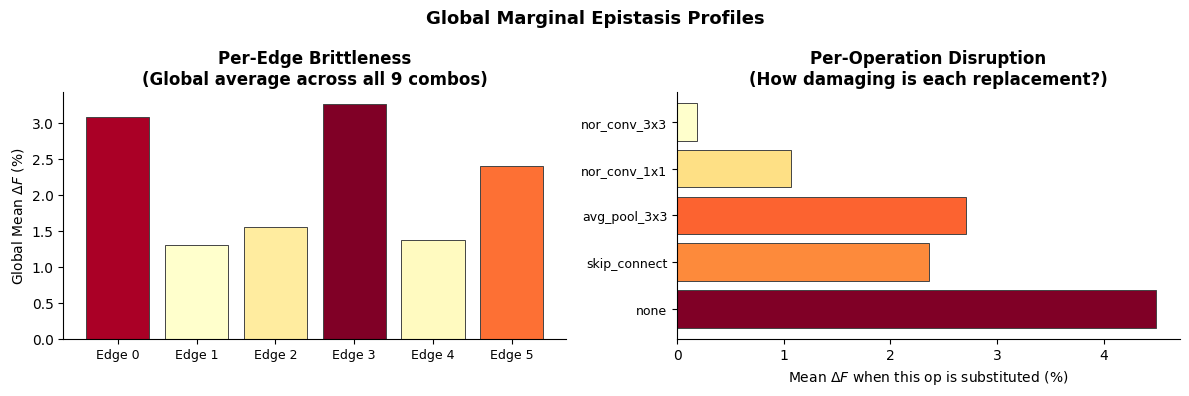

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/epistasis/epistasis_global_marginals.pdf


In [5]:
all_deltas_flat = []
for dataset in DATASETS:
    for hw in HARDWARE:
        mean_delta, _, _ = sensitivity[dataset][hw]
        if mean_delta is not None:
            all_deltas_flat.append(mean_delta)

if all_deltas_flat:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        global_mean = np.nanmean(np.stack(all_deltas_flat, axis=0), axis=0)

    op_disr = op_disruption(global_mean)
    edge_brit = edge_brittleness(global_mean)

    fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4))
    c_edge = plt.cm.YlOrRd((edge_brit - edge_brit.min()) / max(edge_brit.max() - edge_brit.min(), 1e-9))
    axes3[0].bar(range(N_EDGES), edge_brit, color=c_edge, edgecolor="#444", linewidth=0.7)
    axes3[0].set_xticks(range(N_EDGES))
    axes3[0].set_xticklabels([f"Edge {i}" for i in range(N_EDGES)], fontsize=9)
    axes3[0].set_ylabel("Global Mean $\\Delta F$ (%)", fontsize=10)
    axes3[0].set_title("Per-Edge Brittleness\n(Global average across all 9 combos)", fontweight="bold")
    axes3[0].spines[["top", "right"]].set_visible(False)

    c_op = plt.cm.YlOrRd((op_disr - op_disr.min()) / max(op_disr.max() - op_disr.min(), 1e-9))
    axes3[1].barh(range(N_OPS), op_disr, color=c_op, edgecolor="#444", linewidth=0.7)
    axes3[1].set_yticks(range(N_OPS))
    axes3[1].set_yticklabels(OPS_NAMES, fontsize=9)
    axes3[1].set_xlabel("Mean $\\Delta F$ when this op is substituted (%)", fontsize=10)
    axes3[1].set_title("Per-Operation Disruption\n(How damaging is each replacement?)", fontweight="bold")
    axes3[1].spines[["top", "right"]].set_visible(False)

    fig3.suptitle("Global Marginal Epistasis Profiles", fontweight="bold", fontsize=13)
    fig3.tight_layout()
    out_margin = OUT_DIR / "epistasis_global_marginals.pdf"
    fig3.savefig(out_margin, bbox_inches="tight", dpi=180)
    plt.show()
    print(f"Saved → {out_margin}")
else:
    print("No sensitivity data available — run search experiments first.")


## Scientific Interpretation

This analysis is designed to show that our Memetic architecture search finds a true **backbone**, not just a random set of operations.

- **Dark red edges** in the heatmap are those whose replacement causes the largest accuracy drop. These edges are the most epistatic and therefore the most critical in the discovered architectures.
- **Yellow edges** are less sensitive, meaning the network can tolerate a different op there without strongly damaging accuracy.

Because the 3×3 grid is organised by dataset and hardware, we can also see how the backbone shifts across devices:
- Some hardware targets make `conv_3x3` positions more critical.
- Others preserve wider robustness patterns, suggesting the search is adapting the backbone to the device.

This directly supports our proposed algorithm design:
- high-sensitivity edges should be preserved by the discrete PSO component,
- SA acceptance must still allow uphill moves when the backbone is temporarily disrupted,
- GA mutation should focus exploration on lower-sensitivity edges.
